# Fundamentals of Bioimage Analysis: I/O and Processing

## Introduction

Welcome to the 5<sup>nd</sup> notebook of the Bioimage analysis in Python course! This notebook will introduce processing (potentially) large dataset and introduced  ome.zarr, a format created to handle large dataset, reading and processing it using Python.

## Learning Objectives

By completing this notebook, you will be able to:

1. **Read ** file as dask_array
2. **Process dask_array** with file format supporting it such as ome.zarr

## Course Structure

This notebook is divided into three main chapters:

**Chapter 1: Reading as dask_array**

**Chapter 2: Processing dask array**

## Why This Matters

Modern microscopy generates sometime very large images that you may want to process in parrallel using dask

**Let's begin!**

In [1]:
!which python

try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

print(f"Running on colab {IN_COLAB}")

/cygdrive/c/Users/u0094799/.conda/envs/biomage-training-colab/python
Running on colab False


Download the file (only from Colab)

In [ ]:
!wget https://github.com/vib-bic-training/vib_bioimage_analysis_in_python/raw/refs/heads/main/data/02_hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568.zarr.zip
!unzip /content/02_hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568.zarr.zip
!rm /content/02_hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568.zarr.zip

## Preparations
### Library installations on Google Colab
When using Google Colab, we have to make sure that all the libraries that we will use are available in its runtime environment.
Unlike local Python environments that we can reuse after a session, Google Colab will reset the environment after a certain amount of time.
Therefore, each time we start a new Google Colab session, we have to install the libraries in the runtime environment. Luckily, Google Colab already comes with many libraries pre-installed. So, we only have to install the libraries that are not pre-installed.

The following code cell will install all required libraries for this notebook.

In [ ]:
# Pre-installed libraries (will be skipped automatically)
!pip install numpy
!pip install matplotlib

# To install
!pip install bioio==3.3.0 bioio-czi==2.6.1 bioio-ome-tiff==1.4.0 bioio-ome-zarr==3.3.0
!pip install dask_image

^C


# Chapter 1: Reading Images as dask array
In this chapter, we will learn how to read microscopy images as dask_array.
We will use the convenient `bioio` library that will handle a lot of the heavy lifting for us.

## 1.1. Reading Files

**Importing the `bioio` library**

We will start by reading files using the `bioio` library. The following code cell will import all the elements from `bioio` that we will use to read files in this notebook.

In [2]:
# Bioio imports
from bioio import BioImage
import tifffile
from scipy import ndimage

**Reading a file**

BioIO utilizes File-System Specification (fsspec) to read directly from remote resources like object storage services (S3, GCS, etc.) and simple http URL (see [documentation](https://bioio-devs.github.io/bioio/OVERVIEW.html#cloud-io-support)). So we **also** can read dataset **remotely**

We can now define a variable containing the path to the image.

```python
url = "https://github.com/vib-bic-training/vib_bioimage_analysis_in_python/raw/refs/heads/main/data/02_hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568.ome.czi"
```

We can then use the `BioImage` class to read the file.

```python
img = BioImage(url)
```

In [4]:
url = "https://github.com/vib-bic-training/vib_bioimage_analysis_in_python/raw/refs/heads/main/data/02_hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568.ome.czi"
img = BioImage(url)
print(f'Dimensions object: {img.dims}')  # returns a Dimensions object
print(f'Dimension order: {img.dims.order}')  # returns string "TCZYX"
print(f'Size of X dimension: {img.dims.X}')  # returns size of X dimension
print(f'Shape: {img.shape}')  # returns tuple of dimension sizes in TCZYX order
print(f'Channel names: {img.channel_names}')  # returns a list of string channel names found in the metadata
print(f'Z dimension pixel size: {img.physical_pixel_sizes.Z}')  # returns the Z dimension pixel size as found in the metadata
print(f'Y dimension pixel size: {img.physical_pixel_sizes.Y}')  # returns the Y dimension pixel size as found in the metadata
print(f'X dimension pixel size: {img.physical_pixel_sizes.X}')  # returns the X dimension pixel size as found in the metadata

Dimensions object: <Dimensions [T: 1, C: 3, Z: 14, Y: 512, X: 512]>
Dimension order: TCZYX
Size of X dimension: 512
Shape: (1, 3, 14, 512, 512)
Channel names: [np.str_('Ch2-T1'), np.str_('ChS1-T2'), np.str_('Ch1-T3')]
Z dimension pixel size: 1.0
Y dimension pixel size: 0.4151329104819196
X dimension pixel size: 0.4151329104819196


We can load the data in a dask array. if the original file format is not chunked in XY, you the smallest chunk will be the XY plane. Some file format are chunked also in XY, such as ome.zarr, in that case you will hav chunk in XY as well

In [5]:
da = img.dask_data
da

dask.array<reshape, shape=(1, 3, 14, 512, 512), dtype=uint16, chunksize=(1, 1, 1, 512, 512), chunktype=numpy.ndarray>

In [3]:

url = "https://drive.google.com/uc?id=1bWxQfjKDD-B0wVKxOrPq0CAPjgaZs42v"
img = BioImage(url)
print(f'Dimensions object: {img.dims}')  # returns a Dimensions object



UnsupportedFileFormatError: BioImage does not support the image: 'https://drive.google.com/uc?id=1bWxQfjKDD-B0wVKxOrPq0CAPjgaZs42v'. You may need to install an extra format dependency. See our list of known plugins in the bioio README here: https://github.com/bioio-devs/bioio for a list of known plugins. You can also call the 'bioio.plugins.dump_plugins()' method to report information about currently installed plugins or the 'bioio.plugin_feasibility_report(image)' method to check if a specific image can be handled by the available plugins.

Here, there is no chunk on XY since we read the images from a czi files, so the images is chunked by z and channels.

If we use a format (like ome.zarr) supporting full chunk, we would have some in XY as well and take full benefit of it.


But old one, **what is ome.zarr** ?

OME-Zarr offers a range of advantages for researchers such as

- Fast, on-demand access to chunked data, enabling efficient streaming, subsetting and visualization 
- Native support for multiscale datasets (image pyramids)
- Efficient parallel writes, especially to remote storage
- Rich, community-driven metadata layouts and specifications that integrate image data, segmentation masks, and analysis results in one unified, hierarchical structure

<img src="https://www.eurobioimaging.eu/wp-content/uploads/monolithic-vs-chunked-300dpi-1920x2806.png" alt="isolated" width="720"/>

__Image credits: 'monolithic-vs-chunked' by Henning Falk, ©2022 NumFOCUS, used under a CC BY 4.0 license.__

In [4]:
img_zarr = BioImage('C:\\Users\\u0094799\\Documents\\PRESENTATIONS\\2026_Python_for_bioImageAnalysis\\data\\02_hela_prolongdiamond_dapi_tubulin-af488_mitochondria-af568.zarr')

img_da = img_zarr.dask_data
img_da

c:\Users\u0094799\.conda\envs\biomage-training-colab\Lib\site-packages\zarr\core\metadata\v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)


dask.array<reshape, shape=(1, 3, 14, 512, 512), dtype=>u2, chunksize=(1, 2, 2, 96, 96), chunktype=numpy.ndarray>

We could also generate a `dask.array.core.Array` from a nunpy array by doing

```python
img_da = da.from_array(img,
                       chunks=(500, 500),
                       )

```
where `img` is a `numpy.ndarray` and `img_da` is the `dask.array.core.Array`

### Extract a single plane for the demo

In [5]:
import numpy as np

# Single plane as a numpy
single_plane_np = img_zarr.data[0, 2, 6, :, :].squeeze()

#Single plane as a dask array
single_plane_da = img_da[0, 2, 6, :, :]

c:\Users\u0094799\.conda\envs\biomage-training-colab\Lib\site-packages\zarr\core\metadata\v2.py:190: ZarrUserWarning: Found an empty list of filters in the array metadata document. This is contrary to the Zarr V2 specification, and will cause an error in the future. Use None (or Null in a JSON document) instead of an empty list of filters.
  warnings.warn(msg, ZarrUserWarning, stacklevel=1)


Here, we load the image from the ome.zarr, and then using .data extracted :
- a plane as a numpy.ndarray using `.data[0, 2, 6, :, :]` (3<sup>nd</sup> channel, 8<sup>th</sup> Z )and then remove all single dimension with `.squeeze()`
- a plane as `dask.array.core.Array` by simply take a subpart of the whole dask array.

Display the image from the dask array

When `.compute()` is called, the execution of the function is triggered, in that case it wil perform the extraction of the single plane and return `numpy.ndarray` allowing us to se a regular function using a `numpy.ndarray` to show the image.

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: title={'center': 'Channel 2 - Z plane 7'}>,
 <matplotlib.image.AxesImage at 0x22606e86360>)

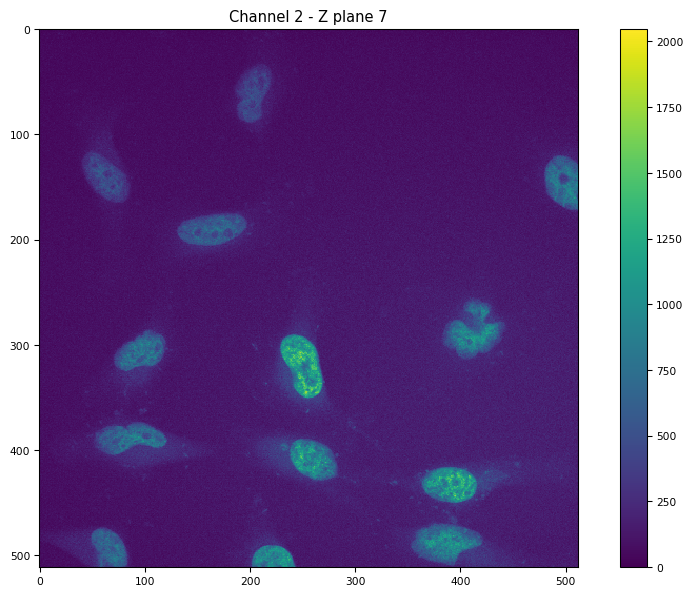

In [6]:
# Display
tifffile.imshow(single_plane_da.compute(), title='Channel 2 - Z plane 7')

Let's measure the time to compute a gaussian filter the whole plane at once on the `numpy.ndarray` so we could compare when it's done on the `dask.array.core.Array`

In [7]:
%%timeit -r 3
# Compute time for gaussian filter on a single numpy plane
ndimage.gaussian_filter(single_plane_np, sigma=5, mode='constant')


3.91 ms ± 50.3 μs per loop (mean ± std. dev. of 3 runs, 100 loops each)


### Filter a dask array using **map_blocks**
Let's use a gaussian blur to filter this plane

We can use `dask.array.map_blocks` to apply a function to each chunk (or block) of the dask array.

In [8]:
from scipy import ndimage

filtered = single_plane_da.map_blocks(
            ndimage.gaussian_filter, 
            sigma=5, 
            mode='constant'
            )
filtered

dask.array<gaussian_filter, shape=(512, 512), dtype=uint16, chunksize=(96, 96), chunktype=numpy.ndarray>

Let's measure the time to compute a gaussian filter the whole plane at once on the `dask.array.core.Array` in threads and compute scheduler

In [9]:
%%timeit -r 3
filtered.compute(scheduler='threads')

28.4 ms ± 1.05 ms per loop (mean ± std. dev. of 3 runs, 10 loops each)


In [10]:
%%timeit -r 3
filtered.compute(scheduler='processes')

1.52 s ± 53.1 ms per loop (mean ± std. dev. of 3 runs, 1 loop each)


Performance comparison: Applying the gaussian filter on each chunk is faster when using multi-threading than when using multi-processing, since threads share memory, different processes doesn't and need to send data back and forth, which can create considerable overhead.

Let's compare the 2 versions, gaussian blur on `numpy.ndarray` and `dask.array.core.Array`

Gaussian blur on whole image


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x22607aa1520>)

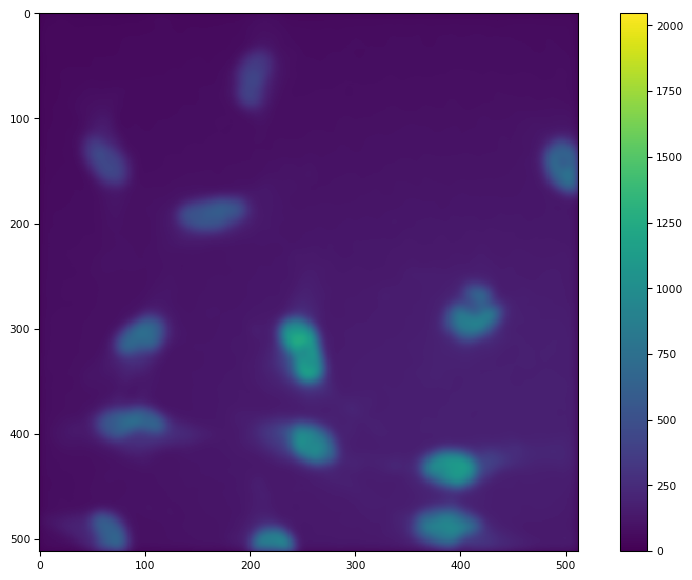

In [11]:
print('Gaussian blur on whole image')
filtered_ndimage = ndimage.gaussian_filter(single_plane_np, sigma=5, mode='constant')
tifffile.imshow(filtered_ndimage)

Gaussian blur on dask.array.map_blocks


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x22607a081a0>)

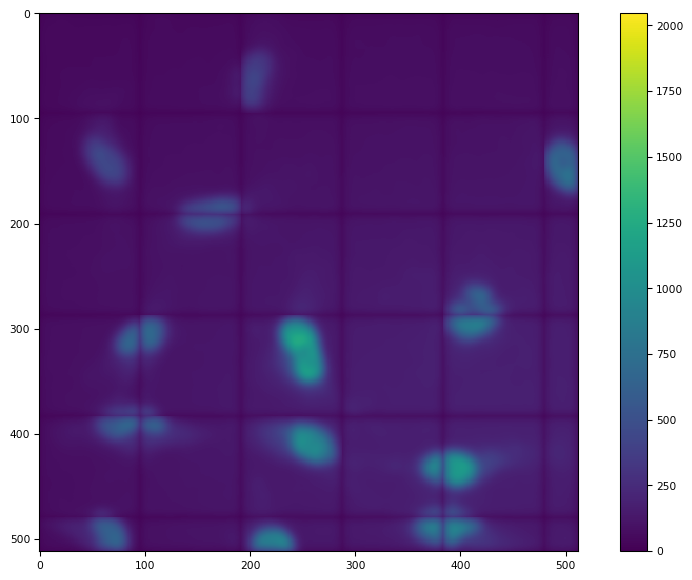

In [12]:
print('Gaussian blur on dask.array.map_blocks')
tifffile.imshow(filtered)

Here we see the border artifact of the bluring, which we could avoid if we used `map_overlap` instead of `map_blocks`. Using `map_blocks` will make each block share a neighboring zones between blocks of the array, so we will have overlaping area  and then trim away the neighboring strips once the funciton has been applied. `depth` is the parameters used to define the overlap part, here 11

In [13]:
filtered_overlap = \
    single_plane_da.map_overlap(
            ndimage.gaussian_filter, # the function to apply to each chunk
            sigma=5, # arguments to the function
            mode='constant',
            depth=11,
            )
filtered_overlap

dask.array<_trim, shape=(512, 512), dtype=uint16, chunksize=(96, 96), chunktype=numpy.ndarray>

Gaussian blur on dask.array.map_overlap with depth 11


(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x22607c301a0>)

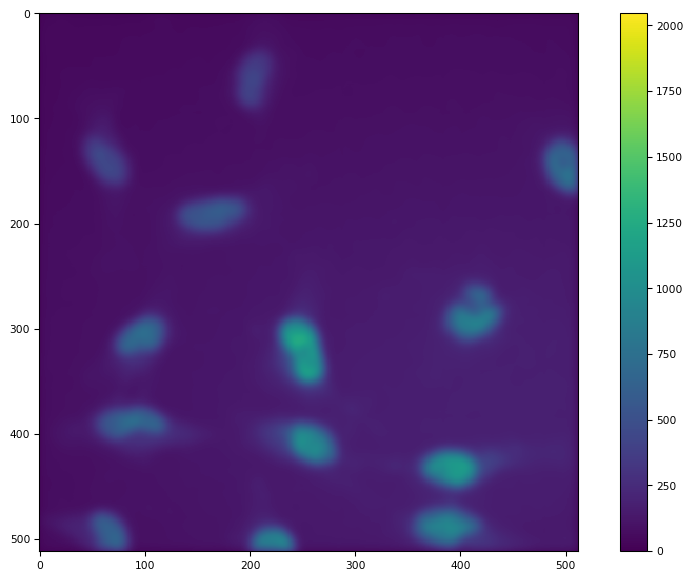

In [14]:
print('Gaussian blur on dask.array.map_overlap with depth 11')
tifffile.imshow(filtered_overlap.compute())

### Dask Image Features

Let's create a  binary from this image and blur using  `dask_image.ndfilters`

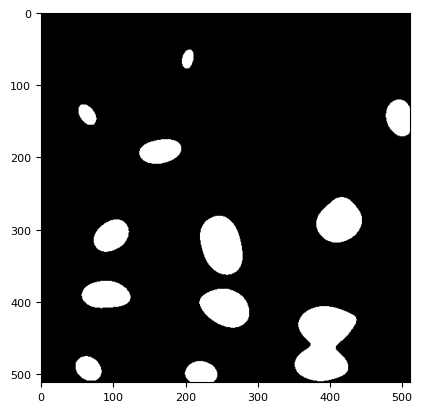

In [16]:
from dask_image import ndfilters
import matplotlib.pyplot as plt

seg_da = (ndfilters.gaussian_filter(single_plane_da, sigma=10, mode='constant') > 300)
plt.imshow(seg_da, cmap='gray')
plt.show()

Now, generate the connected component and label the different cells

(<Figure size 988.8x604.8 with 2 Axes>,
 <Axes: >,
 <matplotlib.image.AxesImage at 0x22609fb3650>)

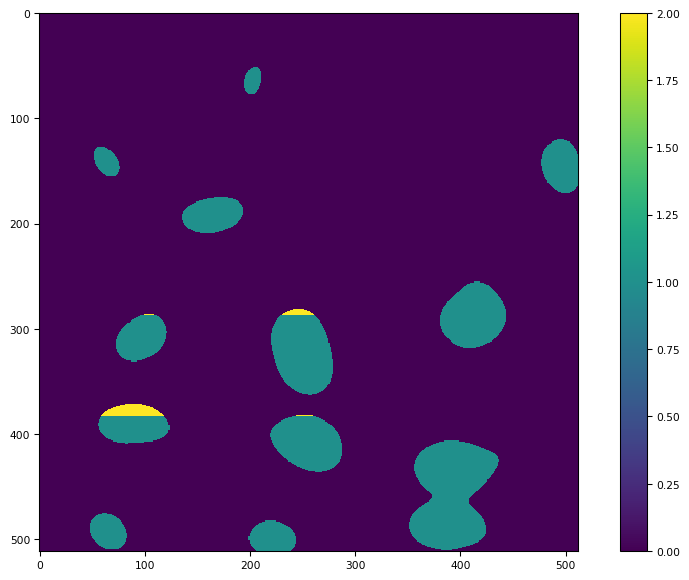

In [18]:
# Let's calculate connected components on each chunk of the segmentation image

def connected_components(im):
    return ndimage.label(im)[0]

labels = seg_da.map_blocks(connected_components)

tifffile.imshow(labels)

It's failing since the label are perfomed by tiles, so we need a dedicated method using the `ndmeasure.label` from `dask_image.ndmeasure.label`. Also, we rechunk the dask array from chunk of 96x96 to 256x256.

In [19]:
from dask_image import ndmeasure

# Rechunk the image to 4 blocks of 256x256
img_da = single_plane_da.rechunk(256, 256)
# Apply a gaussian filter
seg_da = (ndfilters.gaussian_filter(img_da, sigma=10, mode='constant') > 300)
# Label the binary
labels_da, num_features = ndmeasure.label(seg_da)
labels_final = labels_da.compute()



Plot the result

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

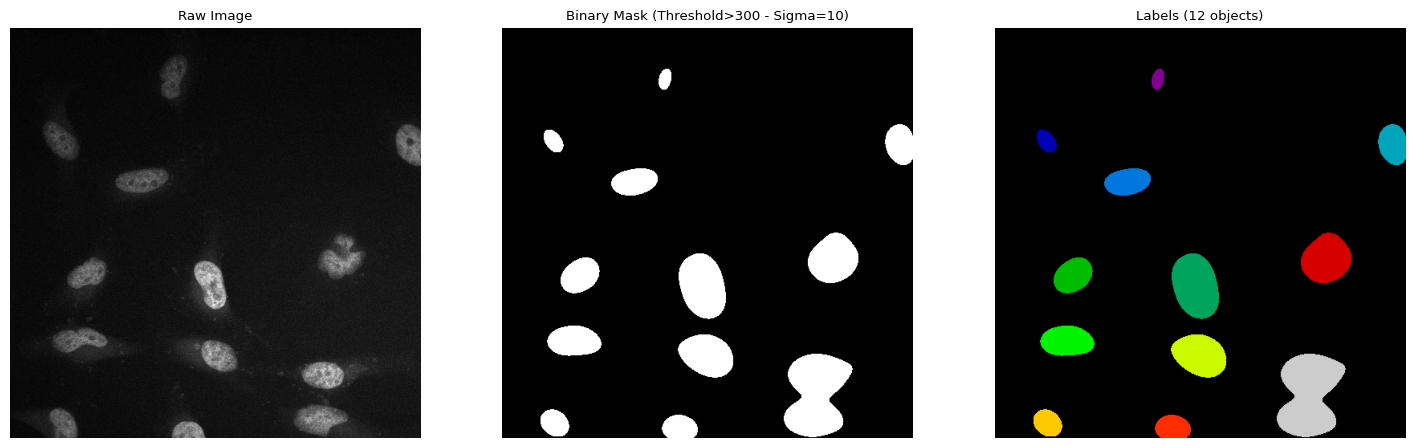

In [129]:
image_np = img_da.compute()
binary_np = seg_da.compute()
labels_np = labels_da.compute()

# 2. Create a side-by-side plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Original Image
axes[0].imshow(image_np, cmap='gray')
axes[0].set_title("Raw Image")
axes[0].axis('off')

# Plot 2: Binary Mask (Segmented)
axes[1].imshow(binary_np, cmap='gray')
axes[1].set_title("Binary Mask (Threshold>300 - Sigma=10)")
axes[1].axis('off')

# Plot 3: Labels (Colored)
# We mask the background (0) to keep it clean
im = axes[2].imshow(labels_final, cmap='nipy_spectral')
axes[2].set_title(f"Labels ({num_features.compute()} objects)")
axes[2].axis('off')

If you are using chunks of 256 on a 512x512 image, you have 4 chunks and 4 internal boundaries instead of 36 one

Why Rechunking Improves Performance:

- Simplified Label Fusion: The most expensive part of `ndmeasure.label` is "stitching" objects that cross boundaries. Reducing the number of chunks from 36 (96x96) to 4 (256x256) drastically simplifies the mathematical logic needed to resolve global labels.
- Reduced Data Redundancy: Spatial filters (like Gaussian) require a "halo" of neighbor pixels. Fewer chunks mean fewer overlapping regions, reducing the amount of redundant data Dask has to copy and communicate between tasks.
- Lower Scheduler Overhead: Every chunk adds a management cost. By increasing chunk size, you spend less time on "task administration" and more time on actual image processing.


Exercice : do not rechunk and see how long it takes with smaller chunk size (128 instead of 256) . For me it is 16 times slower !

## References:
- [Dask](https://docs.dask.org/en/stable/) 🔗
- [Dask-image](https://image.dask.org/en/latest/) 🔗
- [bioio-conversion](https://github.com/bioio-devs/bioio-conversion) 🔗